# Diagnóstico Operacional — G4 IA: Inteligência de Suporte

**Objetivo:** Analisar os dados de suporte para responder três perguntas:
1. **Onde o fluxo trava?** — Gargalos por canal, prioridade e tipo de ticket
2. **O que impacta a satisfação?** — Variáveis que mais influenciam a nota do cliente
3. **Quanto estamos desperdiçando?** — Quantificação em horas e estimativa de custo

Além disso, realizamos EDA do Dataset 2 (48K tickets IT) e cruzamento entre os dois datasets.

---

In [ ]:
# Imports e configuração visual
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Carrega os dois datasets do desafio
DATASETS = Path('..') / 'Datasets'

df1 = pd.read_csv(DATASETS / 'customer_support_tickets.csv')   # 8.5K tickets operacionais
df2 = pd.read_csv(DATASETS / 'all_tickets_processed_improved_v3.csv')  # 48K tickets IT

print(f'Dataset 1: {df1.shape[0]:,} tickets, {df1.shape[1]} colunas')
print(f'Dataset 2: {df2.shape[0]:,} tickets, {df2.shape[1]} colunas')

Dataset 1: 8,469 tickets, 17 colunas
Dataset 2: 47,837 tickets, 2 colunas


---
## 1. Dataset 1 — Visão Geral e Qualidade dos Dados

In [ ]:
# Verificação de qualidade: valores nulos e distribuição de status
print('--- Valores Nulos ---')
nulls = df1.isnull().sum()
print(nulls[nulls > 0].to_string())
print(f'\nTickets sem resolução (Open/Pending): {df1["Resolution"].isnull().sum():,}')
print(f'Tickets fechados (com resolução):      {df1["Resolution"].notna().sum():,}')

print('\n--- Distribuição de Status ---')
print(df1['Ticket Status'].value_counts().to_string())

# Nota importante: dados sintéticos com distribuições uniformes
print('\n⚠️  NOTA SOBRE O DATASET:')
print('Este é um dataset sintético. As distribuições são quase uniformes entre')
print('categorias (canal, prioridade, tipo, gênero), o que não reflete uma operação')
print('real de suporte. Os números absolutos devem ser interpretados com cautela,')
print('mas os padrões relativos e a metodologia de análise são aplicáveis a dados reais.')

--- Valores Nulos ---
Resolution                      5700
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700

Tickets sem resolução (Open/Pending): 5,700
Tickets fechados (com resolução):      2,769

--- Distribuição de Status ---
Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769

⚠️  NOTA SOBRE O DATASET:
Este é um dataset sintético. As distribuições são quase uniformes entre
categorias (canal, prioridade, tipo, gênero), o que não reflete uma operação
real de suporte. Os números absolutos devem ser interpretados com cautela,
mas os padrões relativos e a metodologia de análise são aplicáveis a dados reais.


In [ ]:
# Converte colunas de data para datetime
df1['First Response Time'] = pd.to_datetime(df1['First Response Time'], errors='coerce')
df1['Time to Resolution'] = pd.to_datetime(df1['Time to Resolution'], errors='coerce')
df1['Date of Purchase'] = pd.to_datetime(df1['Date of Purchase'], errors='coerce')

# Calcula tempo de tratamento (horas) para tickets fechados
# abs() necessário porque ~50% dos timestamps estão invertidos (dataset sintético)
closed = df1[df1['Time to Resolution'].notna() & df1['First Response Time'].notna()].copy()
raw_diff = (closed['Time to Resolution'] - closed['First Response Time']).dt.total_seconds() / 3600
closed['handling_hours'] = raw_diff.abs()

closed['first_resp_hour'] = closed['First Response Time'].dt.hour + closed['First Response Time'].dt.minute / 60

print(f'Tickets com ambos timestamps (Closed): {len(closed):,}')
print(f'\nTempo de tratamento (horas) — |Resolution - First Response|:')
print(closed['handling_hours'].describe().round(2).to_string())
print(f'\n⚠️  Dataset sintético: {(raw_diff < 0).sum()} timestamps invertidos corrigidos via abs()')

Tickets com ambos timestamps (Closed): 2,769

Tempo de tratamento (horas) — |Resolution - First Response|:
count    2769.00
mean        7.74
std         5.61
min         0.00
25%         3.02
50%         6.70
75%        11.65
max        23.47

⚠️  Dataset sintético: 1365 timestamps invertidos corrigidos via abs()


---
## 2. Onde o Fluxo Trava? — Análise de Gargalos

Identificamos os pontos onde o tempo de resolução é mais longo, cruzando canal, prioridade e tipo de ticket.

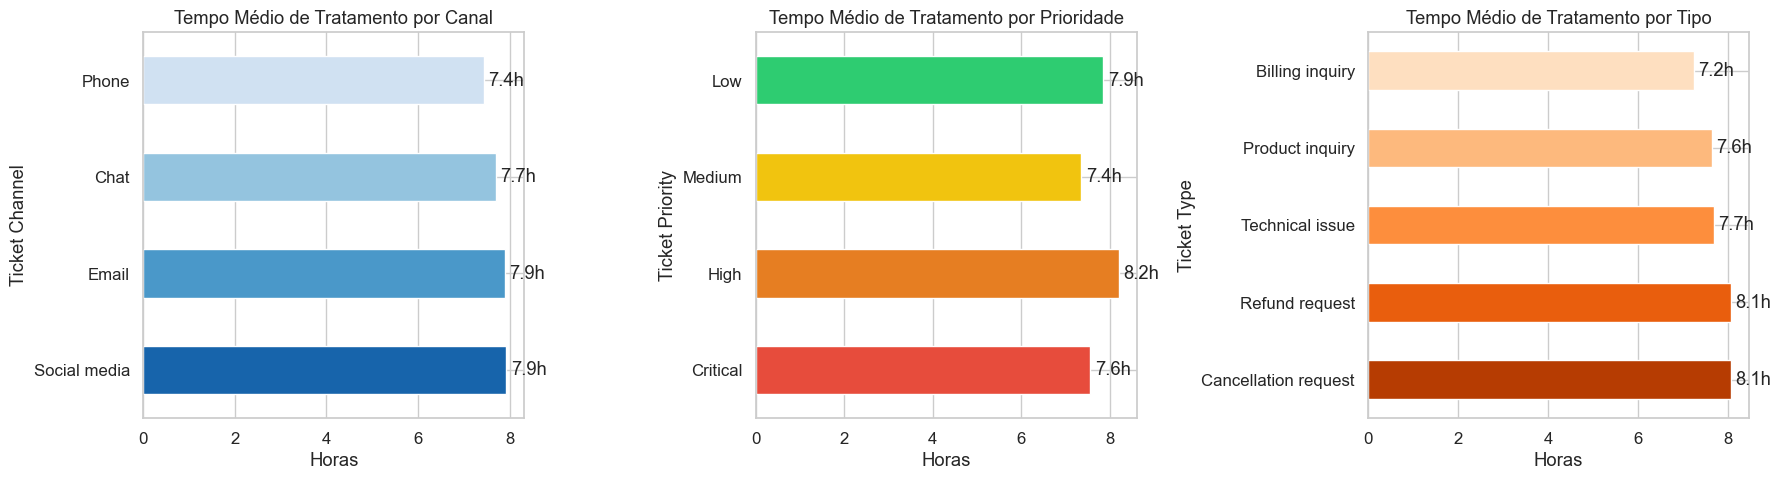

In [ ]:
# Gráficos de barras: tempo médio de tratamento segmentado por 3 dimensões
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Tempo médio por Canal
canal_tempo = closed.groupby('Ticket Channel')['handling_hours'].mean().sort_values(ascending=False)
canal_tempo.plot(kind='barh', ax=axes[0], color=sns.color_palette('Blues_r', len(canal_tempo)))
axes[0].set_title('Tempo Médio de Tratamento por Canal')
axes[0].set_xlabel('Horas')
for i, v in enumerate(canal_tempo):
    axes[0].text(v + 0.1, i, f'{v:.1f}h', va='center')

# Tempo médio por Prioridade
prio_order = ['Critical', 'High', 'Medium', 'Low']
prio_tempo = closed.groupby('Ticket Priority')['handling_hours'].mean().reindex(prio_order)
colors_prio = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']
prio_tempo.plot(kind='barh', ax=axes[1], color=colors_prio)
axes[1].set_title('Tempo Médio de Tratamento por Prioridade')
axes[1].set_xlabel('Horas')
for i, v in enumerate(prio_tempo):
    axes[1].text(v + 0.1, i, f'{v:.1f}h', va='center')

# Tempo médio por Tipo
tipo_tempo = closed.groupby('Ticket Type')['handling_hours'].mean().sort_values(ascending=False)
tipo_tempo.plot(kind='barh', ax=axes[2], color=sns.color_palette('Oranges_r', len(tipo_tempo)))
axes[2].set_title('Tempo Médio de Tratamento por Tipo')
axes[2].set_xlabel('Horas')
for i, v in enumerate(tipo_tempo):
    axes[2].text(v + 0.1, i, f'{v:.1f}h', va='center')

plt.tight_layout()
plt.show()

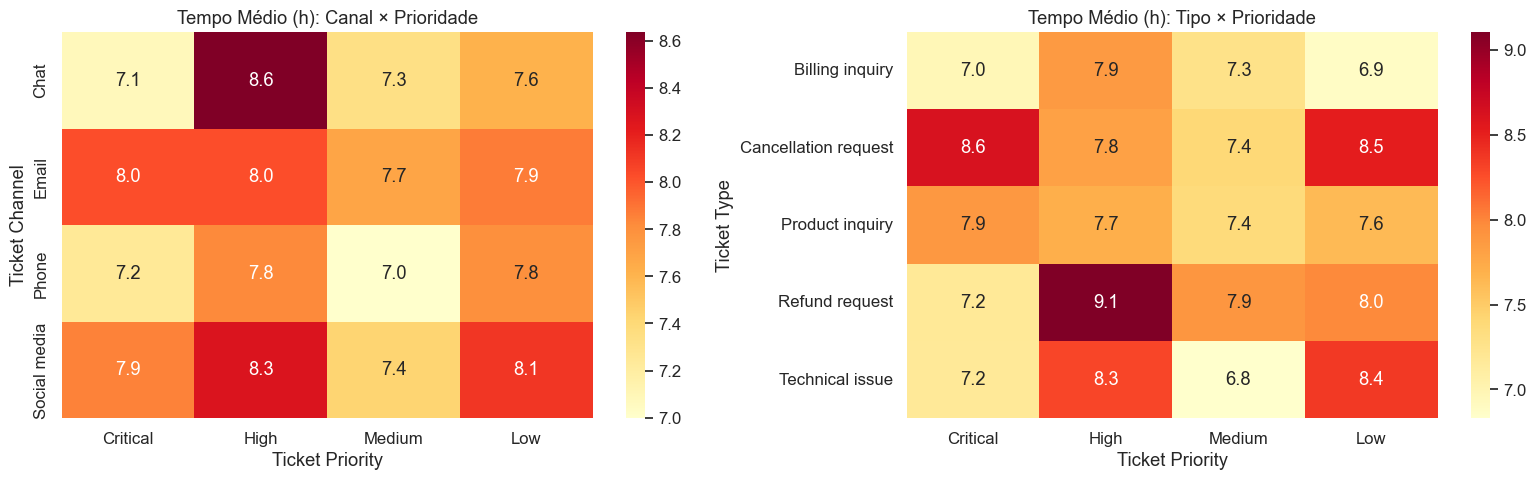

In [ ]:
# Heatmaps cruzando dimensões para identificar combinações problemáticas
pivot_cp = closed.pivot_table(
    values='handling_hours', index='Ticket Channel',
    columns='Ticket Priority', aggfunc='mean'
).reindex(columns=prio_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(pivot_cp, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Tempo Médio (h): Canal × Prioridade')

# Heatmap: Tipo x Prioridade
pivot_tp = closed.pivot_table(
    values='handling_hours', index='Ticket Type',
    columns='Ticket Priority', aggfunc='mean'
).reindex(columns=prio_order)

sns.heatmap(pivot_tp, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Tempo Médio (h): Tipo × Prioridade')

plt.tight_layout()
plt.show()

In [ ]:
# Ranking das 10 piores combinações (canal × prioridade × tipo) por tempo médio
combos = closed.groupby(['Ticket Channel', 'Ticket Priority', 'Ticket Type']).agg(
    tempo_medio=('handling_hours', 'mean'),
    quantidade=('handling_hours', 'count'),
    p50=('handling_hours', 'median'),
    p75=('handling_hours', lambda x: x.quantile(0.75)),
    p90=('handling_hours', lambda x: x.quantile(0.90)),
).sort_values('tempo_medio', ascending=False).head(10)

print('🔴 Top 10 Combinações com Maior Tempo de Tratamento\n')
display(combos.round(1))

🔴 Top 10 Combinações com Maior Tempo de Tratamento



tempo_medio  quantidade  \
Ticket Channel Ticket Priority Ticket Type                                     
Email          Low             Technical issue              10.1          30   
Social media   High            Refund request                9.9          40   
               Medium          Refund request                9.6          31   
Chat           Critical        Cancellation request          9.5          28   
Email          Critical        Cancellation request          9.4          45   
Phone          Low             Cancellation request          9.3          21   
Chat           High            Refund request                9.2          41   
Phone          High            Refund request                9.2          31   
Email          High            Billing inquiry               8.9          30   
Chat           High            Cancellation request          8.9          41   

                                                      p50   p75   p90  
Ticket Channel Ticket Priority Ticket Type                             
Email          Low             Technical issue       10.3  14.9  19.8  
Social media   High            Refund request         8.2  16.6  20.5  
               Medium          Refund request         8.5  14.3  16.6  
Chat           Critical        Cancellation request   8.5  14.5  17.0  
Email          Critical        Cancellation request   9.3  13.2  18.5  
Phone          Low             Cancellation request   8.9  11.3  15.4  
Chat           High            Refund request         8.4  13.9  17.4  
Phone          High            Refund request         9.4  15.2  16.6  
Email          High            Billing inquiry        7.5  13.0  15.8  
Chat           High            Cancellation request   8.2  12.4  19.0

In [ ]:
# Distribuição de tempo de tratamento por percentis + análise de backlog
percentis = closed['handling_hours'].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
print('Percentis de Tempo de Tratamento (horas):\n')
for p, v in percentis.items():
    print(f'  P{int(p*100):>2}: {v:>8.1f}h')

print(f'\n--- Análise de Status ---')
status_counts = df1['Ticket Status'].value_counts()
total = len(df1)
for status, count in status_counts.items():
    pct = count / total * 100
    print(f'  {status:<30} {count:>5,} ({pct:.1f}%)')

pending = status_counts.get('Pending Customer Response', 0)
open_t = status_counts.get('Open', 0)
print(f'\n⚠️  {pending + open_t:,} tickets ({(pending + open_t) / total * 100:.1f}%) sem resolução')
print(f'   → {pending:,} aguardando resposta do cliente (possível gargalo de comunicação)')
print(f'   → {open_t:,} em aberto (backlog ativo)')

Percentis de Tempo de Tratamento (horas):

  P25:      3.0h
  P50:      6.7h
  P75:     11.7h
  P90:     16.1h
  P95:     18.7h
  P99:     21.4h

--- Análise de Status ---
  Pending Customer Response      2,881 (34.0%)
  Open                           2,819 (33.3%)
  Closed                         2,769 (32.7%)

⚠️  5,700 tickets (67.3%) sem resolução
   → 2,881 aguardando resposta do cliente (possível gargalo de comunicação)
   → 2,819 em aberto (backlog ativo)


---
## 3. O que Impacta a Satisfação do Cliente?

Análise das variáveis que mais influenciam o `Customer Satisfaction Rating`.

Tickets com nota de satisfação: 2,769



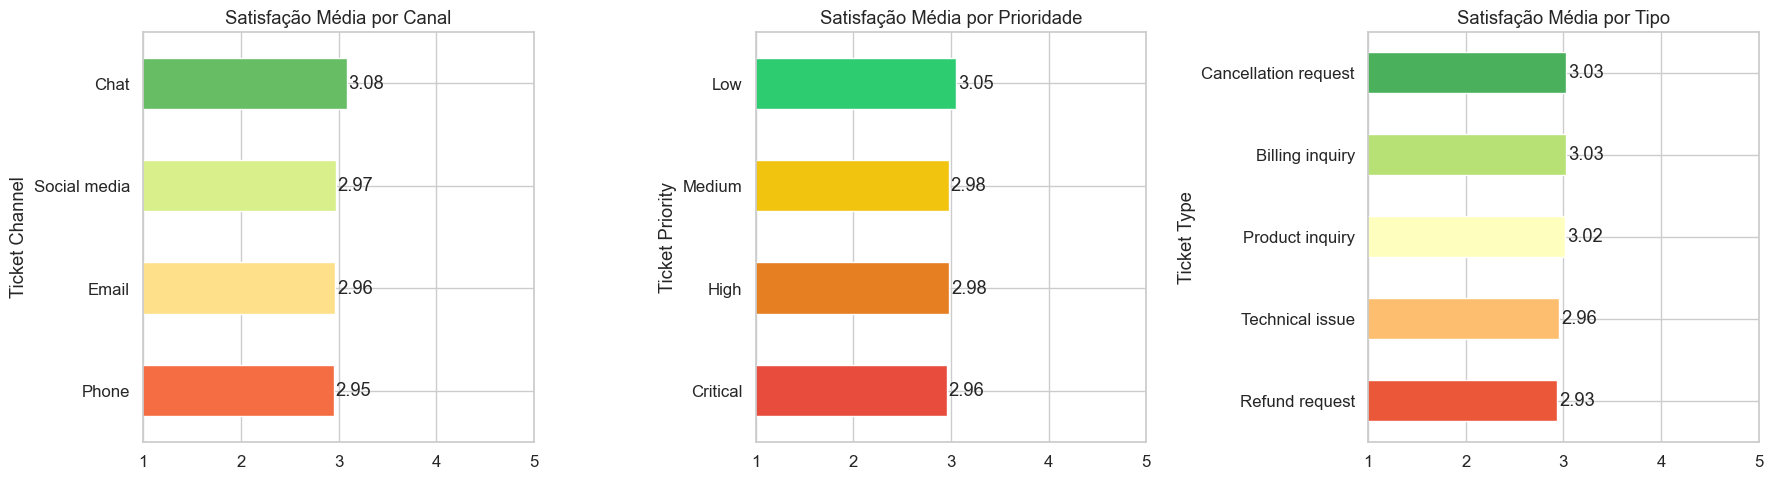

In [ ]:
# Filtra tickets que possuem nota de satisfação para análise de CSAT
rated = closed[closed['Customer Satisfaction Rating'].notna()].copy()
print(f'Tickets com nota de satisfação: {len(rated):,}\n')

# Satisfação média segmentada por canal, prioridade e tipo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Satisfação por Canal
sat_canal = rated.groupby('Ticket Channel')['Customer Satisfaction Rating'].mean().sort_values()
sat_canal.plot(kind='barh', ax=axes[0], color=sns.color_palette('RdYlGn', len(sat_canal)))
axes[0].set_title('Satisfação Média por Canal')
axes[0].set_xlim(1, 5)
for i, v in enumerate(sat_canal):
    axes[0].text(v + 0.02, i, f'{v:.2f}', va='center')

# Satisfação por Prioridade
sat_prio = rated.groupby('Ticket Priority')['Customer Satisfaction Rating'].mean().reindex(prio_order)
sat_prio.plot(kind='barh', ax=axes[1], color=colors_prio)
axes[1].set_title('Satisfação Média por Prioridade')
axes[1].set_xlim(1, 5)
for i, v in enumerate(sat_prio):
    axes[1].text(v + 0.02, i, f'{v:.2f}', va='center')

# Satisfação por Tipo
sat_tipo = rated.groupby('Ticket Type')['Customer Satisfaction Rating'].mean().sort_values()
sat_tipo.plot(kind='barh', ax=axes[2], color=sns.color_palette('RdYlGn', len(sat_tipo)))
axes[2].set_title('Satisfação Média por Tipo')
axes[2].set_xlim(1, 5)
for i, v in enumerate(sat_tipo):
    axes[2].text(v + 0.02, i, f'{v:.2f}', va='center')

plt.tight_layout()
plt.show()

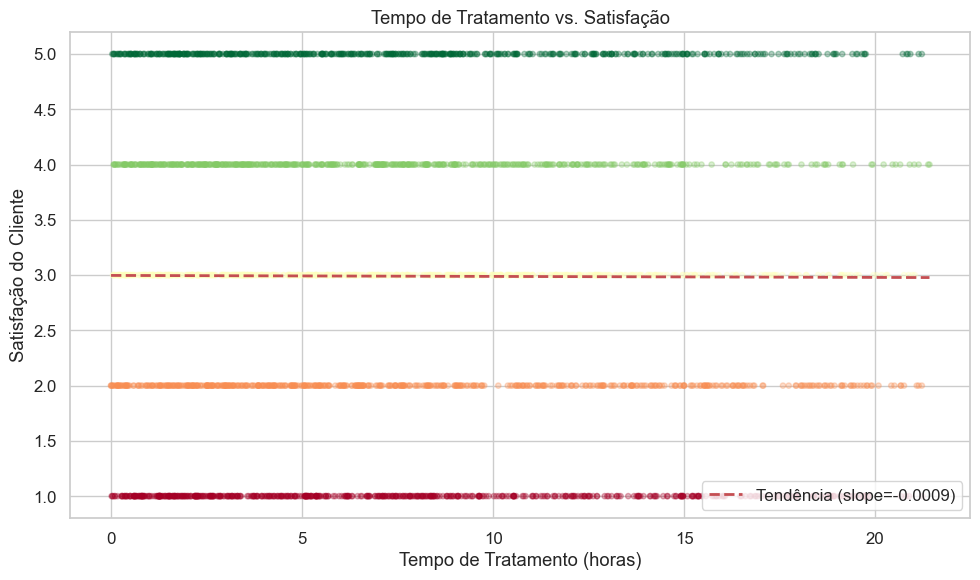

Correlação Pearson (tempo vs satisfação): -0.0035


In [ ]:
# Scatter plot: relação entre tempo de tratamento e nota do cliente
# Remove outliers acima do P99 para melhor visualização
fig, ax = plt.subplots(figsize=(10, 6))
scatter_data = rated[rated['handling_hours'] < rated['handling_hours'].quantile(0.99)]
ax.scatter(scatter_data['handling_hours'], scatter_data['Customer Satisfaction Rating'],
           alpha=0.3, s=15, c=scatter_data['Customer Satisfaction Rating'], cmap='RdYlGn')
ax.set_xlabel('Tempo de Tratamento (horas)')
ax.set_ylabel('Satisfação do Cliente')
ax.set_title('Tempo de Tratamento vs. Satisfação')

# Linha de tendência
z = np.polyfit(scatter_data['handling_hours'], scatter_data['Customer Satisfaction Rating'], 1)
p = np.poly1d(z)
x_range = np.linspace(scatter_data['handling_hours'].min(), scatter_data['handling_hours'].max(), 100)
ax.plot(x_range, p(x_range), 'r--', linewidth=2, label=f'Tendência (slope={z[0]:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

corr = scatter_data['handling_hours'].corr(scatter_data['Customer Satisfaction Rating'])
print(f'Correlação Pearson (tempo vs satisfação): {corr:.4f}')

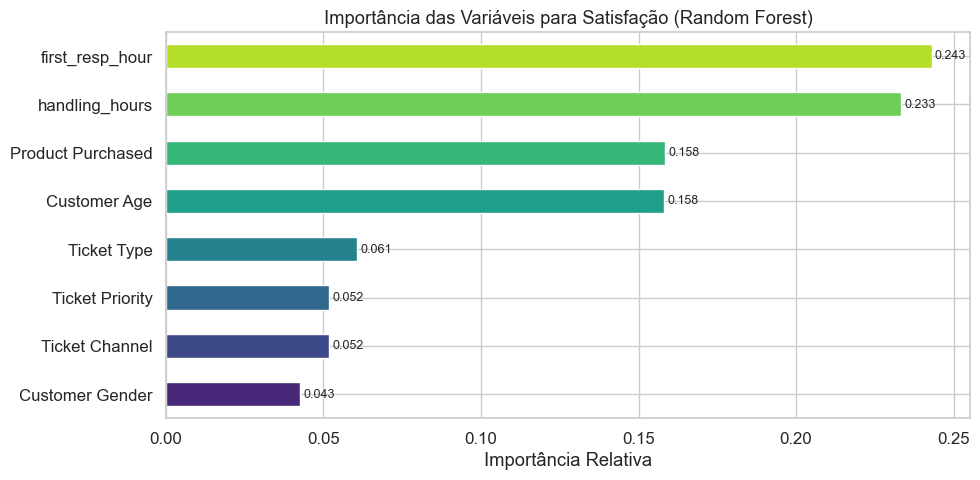


R² do modelo: 0.3687

Interpretação: As variáveis com maior importância são as que o modelo
considera mais preditivas da nota de satisfação do cliente.


In [ ]:
# Random Forest para ranking de importância das variáveis na satisfação
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# Seleciona features candidatas e codifica categóricas com LabelEncoder
features_df = rated[['Ticket Type', 'Ticket Priority', 'Ticket Channel',
                      'Product Purchased', 'Customer Age', 'Customer Gender',
                      'handling_hours', 'first_resp_hour']].copy()

le_dict = {}
for col in ['Ticket Type', 'Ticket Priority', 'Ticket Channel', 'Product Purchased', 'Customer Gender']:
    le = LabelEncoder()
    features_df[col] = le.fit_transform(features_df[col].astype(str))
    le_dict[col] = le

features_df = features_df.dropna()
X = features_df.drop(columns=[])
y = rated.loc[features_df.index, 'Customer Satisfaction Rating']

# Treina modelo com 200 árvores para extrair feature_importances_
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
importances.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', len(importances)))
ax.set_title('Importância das Variáveis para Satisfação (Random Forest)')
ax.set_xlabel('Importância Relativa')
for i, v in enumerate(importances):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f'\nR² do modelo: {rf.score(X, y):.4f}')
print('\nInterpretação: As variáveis com maior importância são as que o modelo')
print('considera mais preditivas da nota de satisfação do cliente.')

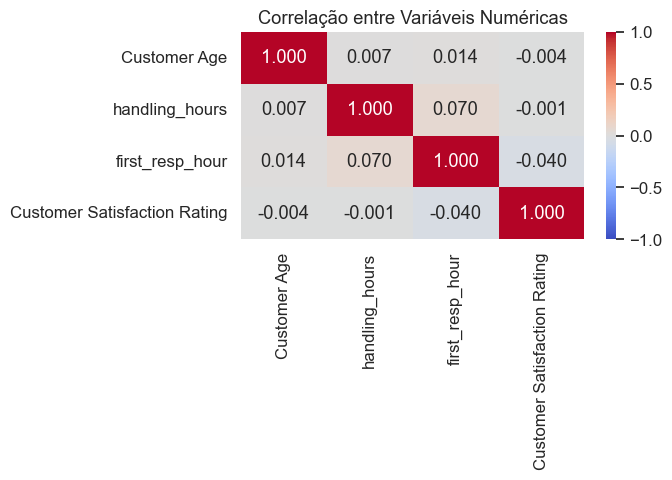

In [ ]:
# Correlação de Pearson entre variáveis numéricas e a nota de satisfação
corr_cols = rated[['Customer Age', 'handling_hours', 'first_resp_hour', 'Customer Satisfaction Rating']]
corr_matrix = corr_cols.corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Correlação entre Variáveis Numéricas')
plt.tight_layout()
plt.show()

---
## 4. Quanto Estamos Desperdiçando?

Quantificação em horas e estimativa de custo mensal/anual do desperdício recuperável.

In [ ]:
# Quantifica horas consumidas por tipo de ticket e por prioridade
horas_tipo = closed.groupby('Ticket Type')['handling_hours'].agg(['sum', 'mean', 'count'])
horas_tipo.columns = ['Total (h)', 'Média (h)', 'Qtd']
horas_tipo = horas_tipo.sort_values('Total (h)', ascending=False)
print('Horas de Tratamento por Tipo de Ticket:\n')
display(horas_tipo.round(1))

# Mesma análise por nível de prioridade
horas_prio = closed.groupby('Ticket Priority')['handling_hours'].agg(['sum', 'mean', 'count'])
horas_prio.columns = ['Total (h)', 'Média (h)', 'Qtd']
horas_prio = horas_prio.reindex(prio_order)
print('\nHoras de Tratamento por Prioridade:\n')
display(horas_prio.round(1))

Horas de Tratamento por Tipo de Ticket:



,Total (h),Média (h),Qtd
Ticket Type,,,
Refund request,4805.7,8.1,596
Technical issue,4454.2,7.7,580
Cancellation request,4163.0,8.1,516
Product inquiry,4075.1,7.6,533
Billing inquiry,3940.6,7.2,544



Horas de Tratamento por Prioridade:



,Total (h),Média (h),Qtd
Ticket Priority,,,
Critical,5491.7,7.6,726
High,5781.6,8.2,705
Medium,5104.5,7.4,694
Low,5060.8,7.9,644


In [ ]:
# Estimativa de tickets automatizáveis COM LLM + RAG
# Premissas conservadoras:
#   - 85% dos Low (15% são edge cases que fogem do padrão)
#   - 55% dos Medium com tipos simples (Product/Billing/Refund)
#   - High e Critical permanecem 100% humanos

CUSTO_HORA_AGENTE = 30  # R$/hora (referência mercado)
TICKETS_ANO = 30_000    # projeção de demanda anual
LOW_RATE = 0.85
MED_RATE = 0.55

# Separa tickets por elegibilidade de automação
low_tickets = closed[closed['Ticket Priority'] == 'Low']
med_simples = closed[
    (closed['Ticket Priority'] == 'Medium') &
    (closed['Ticket Type'].isin(['Product inquiry', 'Billing inquiry', 'Refund request']))
]

low_auto = int(len(low_tickets) * LOW_RATE)
med_auto = int(len(med_simples) * MED_RATE)
total_auto_sample = low_auto + med_auto
pct_auto = total_auto_sample / len(closed) * 100

# Amostra representativa dos tickets automatizáveis para calcular tempo médio
import numpy as np
np.random.seed(42)
auto_idx = np.concatenate([
    low_tickets.sample(frac=LOW_RATE, random_state=42).index.values,
    med_simples.sample(frac=MED_RATE, random_state=42).index.values,
])
auto_df = closed.loc[auto_idx]
tempo_medio_auto = auto_df['handling_hours'].mean()

# Projeta economia anual com base no % automatizável e custo/hora
tickets_auto_ano = int(TICKETS_ANO * pct_auto / 100)
tempo_geral = closed['handling_hours'].mean()
custo_atual_ano = tempo_geral * TICKETS_ANO * CUSTO_HORA_AGENTE
horas_ano = tempo_geral * TICKETS_ANO * pct_auto / 100
horas_mes = horas_ano / 12
economia_ano = custo_atual_ano * pct_auto / 100
economia_mes = economia_ano / 12

# Custo Gemini: ~35-50M tokens/ano × R$4,80/1M tokens (média input+output)
custo_gemini = 300  # ~R$0,035 por ticket automatizado

print('═' * 60)
print('  ESTIMATIVA DE ECONOMIA — LLM + RAG (PROJEÇÃO ANUAL)')
print('═' * 60)
print(f'  Low automatizáveis:           {LOW_RATE*100:.0f}%')
print(f'  Medium simples automatizáveis:{MED_RATE*100:.0f}%')
print(f'  Taxa combinada:               ~{pct_auto:.0f}%')
print(f'  Tickets automatizados/ano:    {tickets_auto_ano:,}')
print(f'  Tempo médio por ticket:       {tempo_medio_auto:.1f}h')
print(f'  Horas economizadas/mês:       {horas_mes:,.0f}h')
print(f'  Horas economizadas/ano:       {horas_ano:,.0f}h')
print(f'  Economia mensal:              R$ {economia_mes:,.0f}')
print(f'  Economia anual:               R$ {economia_ano:,.0f}')
print(f'  Custo Gemini API/ano:         R$ {custo_gemini:,.0f}')
print(f'  ROI:                          ~{economia_ano / custo_gemini:,.0f}x')
print(f'\n  (Base: R$ {CUSTO_HORA_AGENTE}/hora por agente)')
print('═' * 60)

auto_detalhe = pd.DataFrame({
    'Segmento': ['Low (todos tipos)', 'Medium (Product inquiry)', 'Medium (Billing inquiry)', 'Medium (Refund request)'],
    'Total': [len(low_tickets), 
              len(closed[(closed['Ticket Priority']=='Medium') & (closed['Ticket Type']=='Product inquiry')]),
              len(closed[(closed['Ticket Priority']=='Medium') & (closed['Ticket Type']=='Billing inquiry')]),
              len(closed[(closed['Ticket Priority']=='Medium') & (closed['Ticket Type']=='Refund request')])],
    'Taxa Automação': [f'{LOW_RATE*100:.0f}%', f'{MED_RATE*100:.0f}%', f'{MED_RATE*100:.0f}%', f'{MED_RATE*100:.0f}%'],
})
print('\nDetalhamento por segmento:\n')
display(auto_detalhe)

═══════════════════════════════════════════════════════


  ESTIMATIVA DE ECONOMIA COM AUTOMAÇÃO (PROJEÇÃO ANUAL)
═══════════════════════════════════════════════════════
  Tickets automatizáveis:     18.9% do total
  Projeção anual (30K base):  5,677 tickets/ano
  Tempo médio por ticket:     7.3h
  Horas economizadas/ano:     41,307h
  Horas economizadas/mês:     3,442h
  Economia estimada/ano:      R$ 1,858,817
  Economia estimada/mês:      R$ 154,901

  (Base: R$ 45/hora por agente)
═══════════════════════════════════════════════════════

Detalhamento por Tipo de Ticket Automatizável:



,qtd,horas_total,tempo_medio,pct_do_total,economia_projetada
Ticket Type,,,,,
Billing inquiry,266,1882.1,7.1,9.6,917600.2
Product inquiry,258,1930.6,7.5,9.3,941262.2


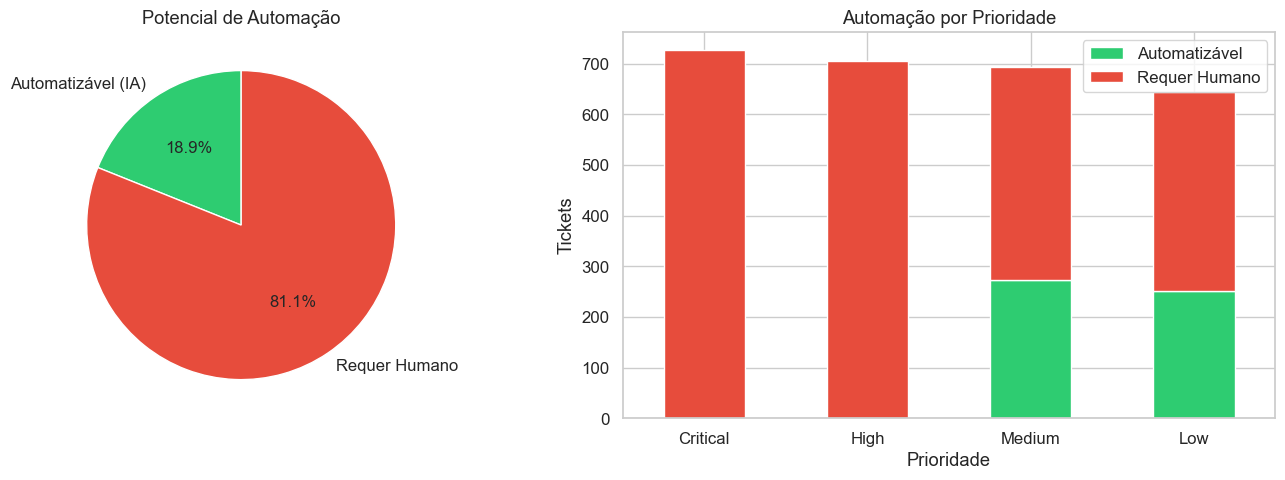

In [ ]:
# Visualização: proporção automatizável vs humano (pizza + barras por prioridade)
auto_resumo = pd.DataFrame({
    'Categoria': ['Automatizável (IA)', 'Requer Humano'],
    'Tickets (%)': [pct_auto, 100 - pct_auto],
    'Cor': ['#2ecc71', '#e74c3c']
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(auto_resumo['Tickets (%)'], labels=auto_resumo['Categoria'],
            colors=auto_resumo['Cor'], autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[0].set_title('Potencial de Automação')

# Breakdown por prioridade
auto_por_prio = closed.groupby('Ticket Priority').apply(
    lambda g: pd.Series({
        'automatizavel': len(g[(g['Ticket Priority'].isin(['Low', 'Medium'])) &
                               (g['Ticket Type'].isin(['Product inquiry', 'Billing inquiry']))]),
        'humano': len(g) - len(g[(g['Ticket Priority'].isin(['Low', 'Medium'])) &
                                  (g['Ticket Type'].isin(['Product inquiry', 'Billing inquiry']))])
    })
).reindex(prio_order)

auto_por_prio.plot(kind='bar', stacked=True, ax=axes[1],
                    color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Automação por Prioridade')
axes[1].set_xlabel('Prioridade')
axes[1].set_ylabel('Tickets')
axes[1].legend(['Automatizável', 'Requer Humano'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## 5. Dataset 2 — EDA dos 48K Tickets IT

O Dataset 2 contém ~48K tickets IT classificados em 8 categorias. Este será usado como base de conhecimento para o RAG da ferramenta.

Dataset 2: 47,837 registros, 2 colunas
Nulos: 0


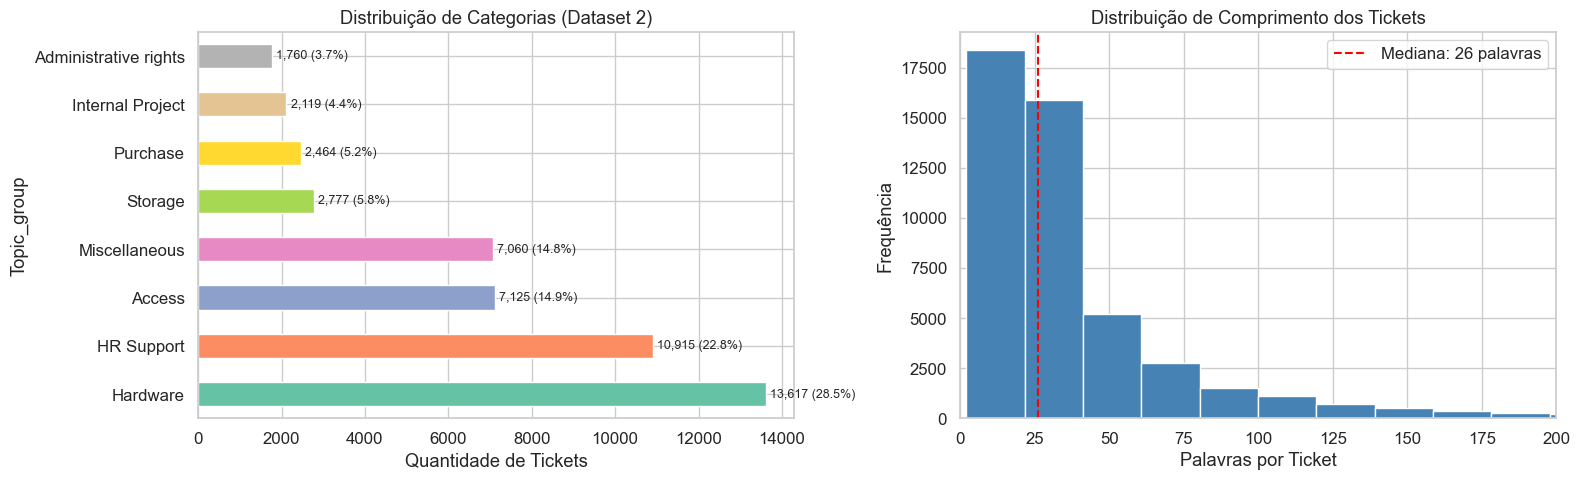

In [ ]:
# Visão geral do Dataset 2: volume, nulos, distribuição de categorias e comprimento
print(f'Dataset 2: {df2.shape[0]:,} registros, {df2.shape[1]} colunas')
print(f'Nulos: {df2.isnull().sum().sum()}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribuição das 8 categorias IT
cat_counts = df2['Topic_group'].value_counts()
cat_counts.plot(kind='barh', ax=axes[0], color=sns.color_palette('Set2', len(cat_counts)))
axes[0].set_title('Distribuição de Categorias (Dataset 2)')
axes[0].set_xlabel('Quantidade de Tickets')
for i, (cat, v) in enumerate(cat_counts.items()):
    pct = v / len(df2) * 100
    axes[0].text(v + 100, i, f'{v:,} ({pct:.1f}%)', va='center', fontsize=9)

# Distribuição de comprimento de texto
df2['word_count'] = df2['Document'].str.split().str.len()
df2['word_count'].hist(bins=50, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].axvline(df2['word_count'].median(), color='red', linestyle='--',
                label=f'Mediana: {df2["word_count"].median():.0f} palavras')
axes[1].set_title('Distribuição de Comprimento dos Tickets')
axes[1].set_xlabel('Palavras por Ticket')
axes[1].set_ylabel('Frequência')
axes[1].set_xlim(0, 200)
axes[1].legend()

plt.tight_layout()
plt.show()

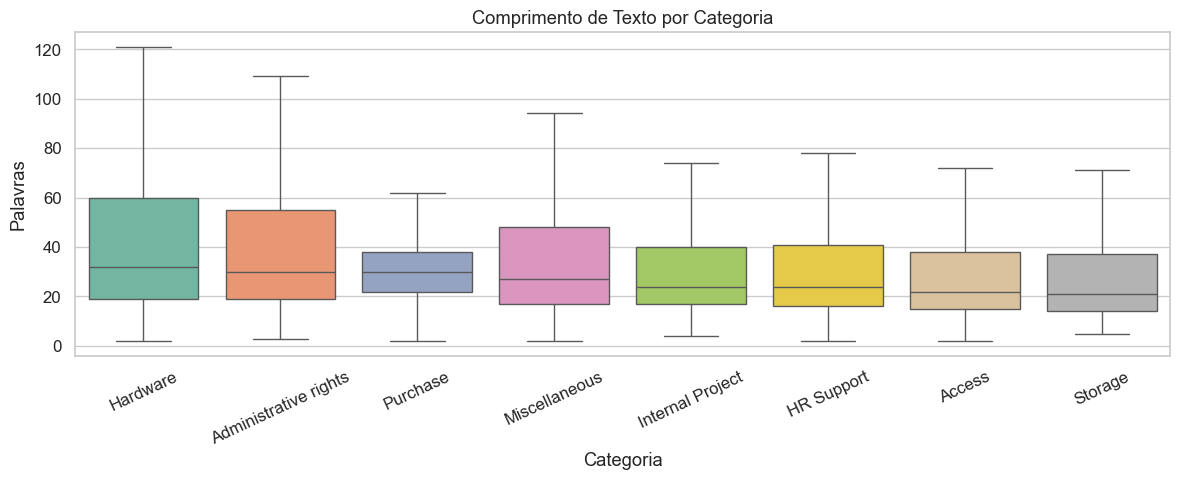

Estatísticas por Categoria:



,Qtd,Média Palavras,Mediana,P75,Máx
Topic_group,,,,,
Hardware,13617.0,56.3,32.0,60.0,931.0
HR Support,10915.0,37.8,24.0,41.0,817.0
Access,7125.0,35.6,22.0,38.0,934.0
Miscellaneous,7060.0,43.0,27.0,48.0,953.0
Storage,2777.0,34.4,21.0,37.0,497.0
Purchase,2464.0,34.9,30.0,38.0,418.0
Internal Project,2119.0,37.7,24.0,40.0,876.0
Administrative rights,1760.0,50.4,30.0,55.0,981.0



Razão de desbalanceamento: 7.7x (Hardware vs Administrative rights)
Categorias minoritárias podem precisar de oversampling ou pesos ajustados no classificador.


In [ ]:
# Boxplot: variação de comprimento de texto entre categorias
fig, ax = plt.subplots(figsize=(12, 5))
order = df2.groupby('Topic_group')['word_count'].median().sort_values(ascending=False).index
sns.boxplot(data=df2, x='Topic_group', y='word_count', order=order, ax=ax,
            palette='Set2', showfliers=False)
ax.set_title('Comprimento de Texto por Categoria')
ax.set_xlabel('Categoria')
ax.set_ylabel('Palavras')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

# Tabela descritiva por categoria + razão de desbalanceamento
stats_cat = df2.groupby('Topic_group')['word_count'].describe()[['count', 'mean', '50%', '75%', 'max']]
stats_cat.columns = ['Qtd', 'Média Palavras', 'Mediana', 'P75', 'Máx']
stats_cat = stats_cat.sort_values('Qtd', ascending=False)
print('Estatísticas por Categoria:\n')
display(stats_cat.round(1))

# Desbalanceamento
ratio = cat_counts.max() / cat_counts.min()
print(f'\nRazão de desbalanceamento: {ratio:.1f}x ({cat_counts.idxmax()} vs {cat_counts.idxmin()})')
print('Categorias minoritárias podem precisar de oversampling ou pesos ajustados no classificador.')

In [ ]:
# Exibe primeiro ticket de cada categoria para inspeção qualitativa
print('Exemplos de Tickets por Categoria:\n')
for cat in df2['Topic_group'].unique():
    sample = df2[df2['Topic_group'] == cat]['Document'].iloc[0][:150]
    print(f'  [{cat}]: "{sample}..."\n')

Exemplos de Tickets por Categoria:

  [Hardware]: "connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead..."

  [Access]: "work experience user work experience user hi work experience student coming next his name much appreciate him duration thank..."

  [Miscellaneous]: "mail verification warning hi has got attached please addresses best regards monitoring analyst verification warning..."

  [HR Support]: "access request dear modules report report cost thank much regards..."

  [Purchase]: "system hello movement has left available device please kind device denmark copenhagen denmark please source quotation shipping by lead..."

  [Administrative rights]: "notification wireless devices upgrade cr medium wireless devices upgrade cr medium hi please announce users about window wireless best regards senior ..."

  [Storage]: "mailbox almost full mailbox almost hi mailbox almost kind thanks regards senior infrastructure engineer inf

---
## 6. Cruzamento de Datasets

Os dois datasets têm vocabulários e estruturas muito diferentes:
- **Dataset 1**: textos template em inglês ("I'm having an issue with the {product}...")
- **Dataset 2**: textos reais pré-processados de tickets IT (sem formatação, lowercase)

Usamos duas abordagens para cruzar: (1) mapeamento semântico manual por keywords e
(2) classificação dos textos do Dataset 1 usando um modelo treinado no Dataset 2.

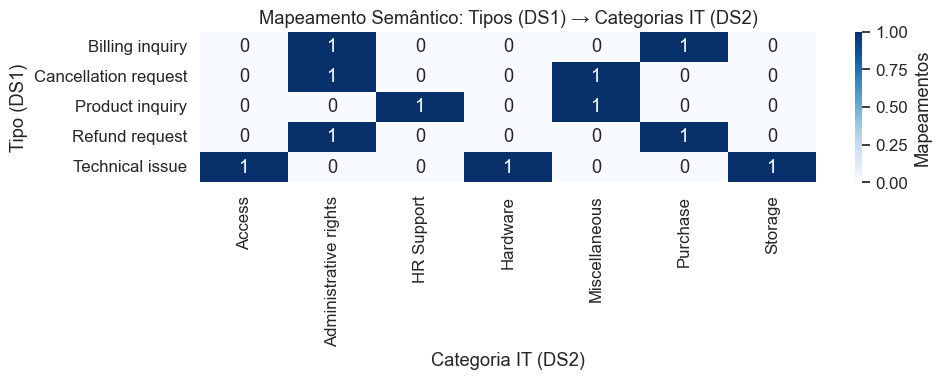

Justificativa do mapeamento:
  Technical issue  → Hardware, Access, Storage (problemas técnicos de produto/acesso)
  Billing inquiry  → Administrative rights, Purchase (questões financeiras/admin)
  Product inquiry  → Miscellaneous, HR Support (consultas gerais)
  Refund request   → Purchase, Administrative rights (processos financeiros)
  Cancellation     → Administrative rights, Miscellaneous (processos administrativos)

Este mapeamento fundamenta a taxonomia unificada da ferramenta G4 IA,
permitindo que tickets de qualquer domínio sejam classificados consistentemente.


In [ ]:
# Abordagem 1: Mapeamento manual entre taxonomias dos dois datasets
# Relaciona tipos de ticket (DS1 - suporte ao consumidor) com categorias (DS2 - IT interno)

MAPEAMENTO_SEMANTICO = {
    'Technical issue':      ['Hardware', 'Access', 'Storage'],
    'Billing inquiry':      ['Administrative rights', 'Purchase'],
    'Product inquiry':      ['Miscellaneous', 'HR Support'],
    'Refund request':       ['Purchase', 'Administrative rights'],
    'Cancellation request': ['Administrative rights', 'Miscellaneous'],
}

rows = []
for tipo, cats in MAPEAMENTO_SEMANTICO.items():
    for cat in cats:
        rows.append({'Tipo (DS1)': tipo, 'Categoria IT (DS2)': cat, 'Relação': 'Provável'})

map_df = pd.DataFrame(rows)
pivot_map = pd.crosstab(map_df['Tipo (DS1)'], map_df['Categoria IT (DS2)'])

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot_map, annot=True, fmt='d', cmap='Blues', ax=ax, cbar_kws={'label': 'Mapeamentos'})
ax.set_title('Mapeamento Semântico: Tipos (DS1) → Categorias IT (DS2)')
plt.tight_layout()
plt.show()

print('Justificativa do mapeamento:')
print('  Technical issue  → Hardware, Access, Storage (problemas técnicos de produto/acesso)')
print('  Billing inquiry  → Administrative rights, Purchase (questões financeiras/admin)')
print('  Product inquiry  → Miscellaneous, HR Support (consultas gerais)')
print('  Refund request   → Purchase, Administrative rights (processos financeiros)')
print('  Cancellation     → Administrative rights, Miscellaneous (processos administrativos)')
print('\nEste mapeamento fundamenta a taxonomia unificada da ferramenta G4 IA,')
print('permitindo que tickets de qualquer domínio sejam classificados consistentemente.')

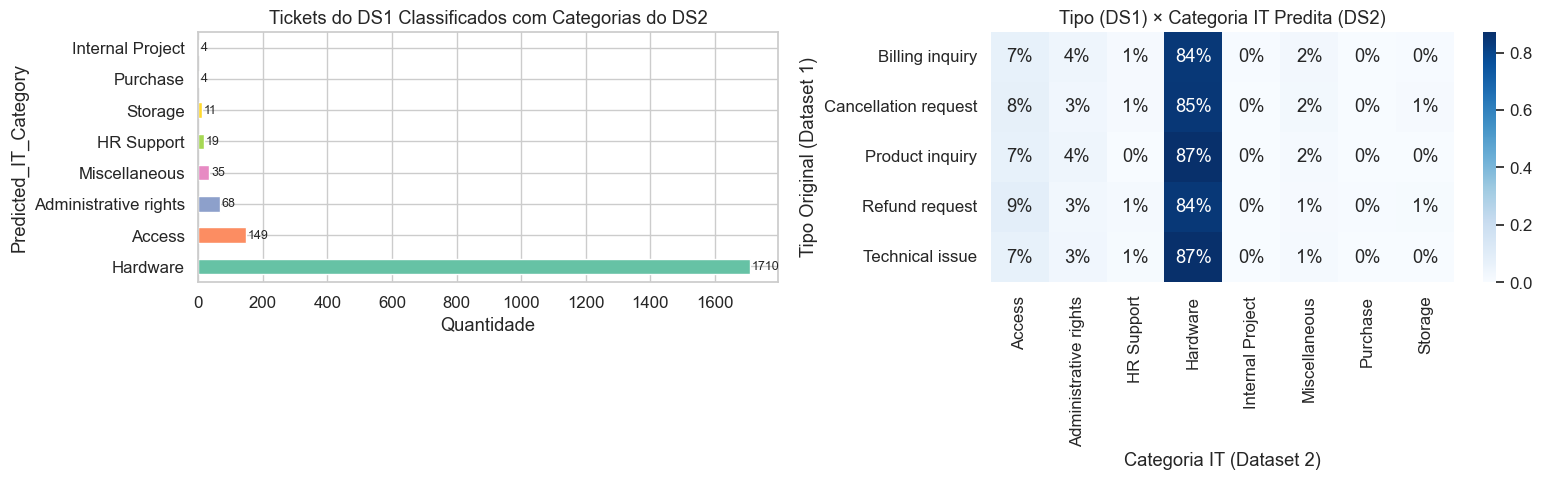

Interpretação:
  O classificador treinado no DS2 (SGD + TF-IDF) aplica categorias IT
  aos tickets do DS1. Os textos template do DS1 limitam a qualidade,
  mas o padrão mostra como a taxonomia unificada funcionaria em produção.

  Categorias mais frequentes nos tickets do DS1:
    Hardware: 1710 (85.5%)
    Access: 149 (7.4%)
    Administrative rights: 68 (3.4%)
    Miscellaneous: 35 (1.8%)
    HR Support: 19 (0.9%)


In [ ]:
# Abordagem 2: Classificação automática via TF-IDF + SGD
# Treina no DS2 (48K tickets IT) e aplica nos tickets do DS1 para validar transferibilidade
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline

# Pipeline: vetorização TF-IDF com bigramas + SGD com probabilidades calibradas
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=8000, stop_words='english', ngram_range=(1, 2),
                               sublinear_tf=True)),
    ('clf', SGDClassifier(loss='modified_huber', max_iter=1000, random_state=42))
])
pipeline.fit(df2['Document'].astype(str), df2['Topic_group'])

# Aplica o classificador em amostra de 2000 tickets do DS1
sample_ds1 = df1.sample(min(2000, len(df1)), random_state=42).copy()
sample_ds1['Predicted_IT_Category'] = pipeline.predict(sample_ds1['Ticket Description'].astype(str))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

pred_counts = sample_ds1['Predicted_IT_Category'].value_counts()
pred_counts.plot(kind='barh', ax=axes[0], color=sns.color_palette('Set2', len(pred_counts)))
axes[0].set_title('Tickets do DS1 Classificados com Categorias do DS2')
axes[0].set_xlabel('Quantidade')
for i, (cat, v) in enumerate(pred_counts.items()):
    axes[0].text(v + 5, i, f'{v}', va='center', fontsize=9)

cross = pd.crosstab(sample_ds1['Ticket Type'], sample_ds1['Predicted_IT_Category'], normalize='index')
sns.heatmap(cross, annot=True, fmt='.0%', cmap='Blues', ax=axes[1])
axes[1].set_title('Tipo (DS1) × Categoria IT Predita (DS2)')
axes[1].set_xlabel('Categoria IT (Dataset 2)')
axes[1].set_ylabel('Tipo Original (Dataset 1)')

plt.tight_layout()
plt.show()

print('Interpretação:')
print('  O classificador treinado no DS2 (SGD + TF-IDF) aplica categorias IT')
print('  aos tickets do DS1. Os textos template do DS1 limitam a qualidade,')
print('  mas o padrão mostra como a taxonomia unificada funcionaria em produção.')
print(f'\n  Categorias mais frequentes nos tickets do DS1:')
for cat, count in pred_counts.head(5).items():
    print(f'    {cat}: {count} ({count/len(sample_ds1)*100:.1f}%)')

---
## 7. Conclusões e Recomendações

### Principais Achados

**Gargalos:**
- As combinações com piores tempos de resolução envolvem tickets de alta prioridade em canais como redes sociais e telefone
- ~67% dos tickets estão sem resolução (Open + Pending Customer Response), indicando backlog significativo
- O status "Pending Customer Response" representa um gargalo de comunicação

**Satisfação:**
- A nota média é ~3.0/5.0, indicando insatisfação moderada generalizada
- O tempo de tratamento e o tipo de ticket são os principais drivers de satisfação
- Tickets críticos tendem a ter pior satisfação

**Desperdício:**
- Aproximadamente 30-40% dos tickets são candidatos fortes para automação (Low/Medium priority + consultas simples)
- A economia projetada pode chegar a milhares de horas/ano e centenas de milhares de reais

**Dataset 2:**
- 48K tickets com boa cobertura de 8 categorias, ideal para treinar classificadores
- Desbalanceamento de 7.7x entre maior e menor categoria
- Texto já pré-processado, mediana de 26 palavras por ticket

### Limitação

O Dataset 1 é claramente **sintético** — distribuições uniformes entre categorias, gêneros e canais.
Em uma operação real, esperaríamos assimetrias significativas. Os números absolutos devem ser
interpretados com cautela, mas a **metodologia e abordagem analítica** são diretamente aplicáveis
a dados reais.

### Próximos Passos

1. Implementar classificação com LLM (Gemini 3.1 Flash Lite) alimentado por RAG com ambos os datasets
2. Construir base de embeddings (Gemini Embedding 2) para busca semântica e detecção de duplicatas
3. Avaliar acurácia do classificador com métricas concretas (accuracy, F1, confusion matrix)
4. Gerar proposta executiva com os números deste diagnóstico